# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:01:57.591
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:05.299


In [207]:
mnase_analysis_rep1.compute_replication_timing()
mnase_analysis_rep2.compute_replication_timing()

In [209]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver

# todo: add replication 2
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep2)

In [210]:
solver.set_chrom(10)

In [355]:
from src.timer import Timer

timer = Timer()

n = len(solver.chr_genes)

all_fs = None
for bin_idx in np.arange(n):
    
    # Total counts in this bin is 0, skip
    if (not solver.chr_bin_curves1.iloc[bin_idx].sum() > 0):
        continue

    solver.select_bins([bin_idx])
    solver.solve(verbose=False)
    if bin_idx % 40 == 0:
        timer.print_time(f"{bin_idx}/{n}")
    current_f = solver.f
    if bin_idx == 0:
        all_fs = np.zeros((n, current_f.shape[0]))
    all_fs[bin_idx] = current_f.flatten()
all_fs = all_fs.T

0/340 - 00:00:00.599
40/340 - 00:00:27.012
80/340 - 00:00:53.605
120/340 - 00:01:20.008
160/340 - 00:01:45.463
200/340 - 00:02:12.264
240/340 - 00:02:35.898
280/340 - 00:03:02.205
320/340 - 00:03:28.795


In [356]:
from src.sgd import get_chromosome_length

In [375]:
postg1_indices = solver.config1.get_Hpositions_for_phase('postG1')
postg1_tps = solver.config1.get_phase_timepoints_for_phase('postG1')

In [379]:
g1lens =solver.config1.get_g1_lens()
cg1_len = g1lens[1]

Text(0, 0.5, 'Replicating timing, min')

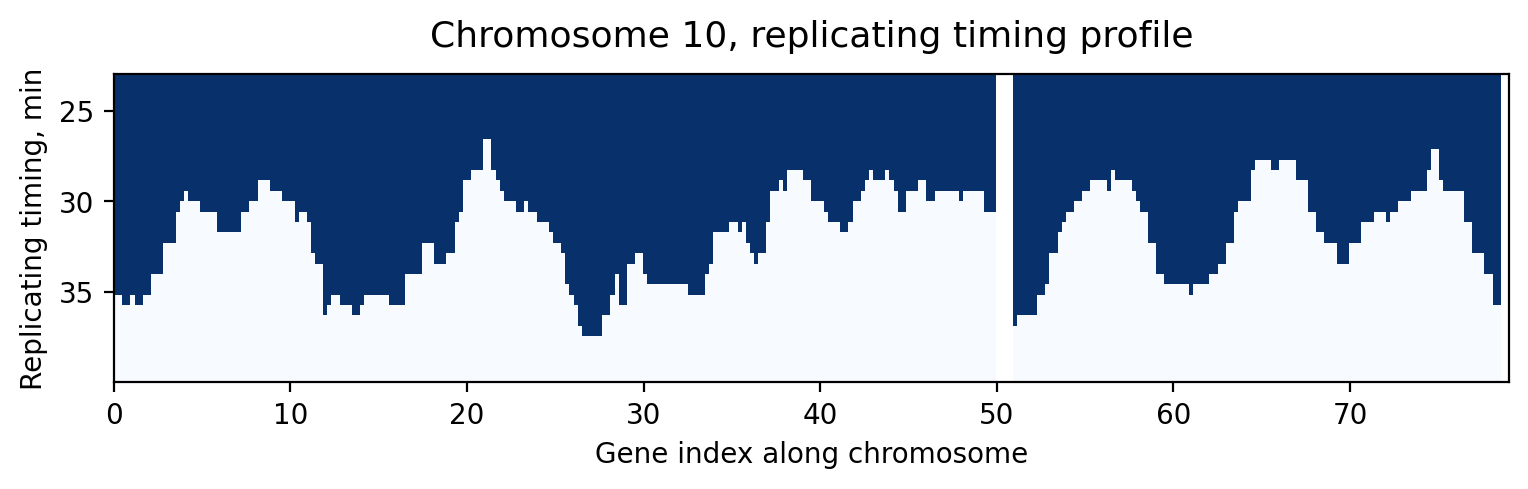

In [411]:
chrom_len = get_chromosome_length(solver.chrom)
plt.figure(figsize=(9, 2))

postg1_f = all_fs[postg1_indices]
postg1_f[postg1_f == 0] = np.nan

plt.imshow(postg1_f, origin='lower', aspect='auto', 
           extent=[0, len(postg1_f), postg1_tps[0]+cg1_len, postg1_tps[-1]+cg1_len],
          vmin=1, vmax=2, cmap='Blues_r')
plt.title(f"Chromosome {solver.chrom}, replicating timing profile", 
    fontsize=13, pad=10)
plt.yticks(np.arange(20, 40, 5))

plt.ylim(40, 23)
plt.xlabel("Gene index along chromosome")
plt.ylabel("Replicating timing, min")

In [412]:
# Deconvolve the replication for every 10k window? Or just for the genes?
# For every 10k window, it will be easier to compare with published timing profiles
# Story revolves around replicating timing and we may look at ORCs for non-gene
# analysis..
